# 1. Dataset Split Verification
This cell checks the number of total, labeled, and background images in the train, validation, and test sets.

In [ ]:
import os

base_path = "URPC2020/URPC2020"
splits = ['train', 'valid', 'test']

for split in splits:
    images_dir = os.path.join(base_path, split, 'images')
    labels_dir = os.path.join(base_path, split, 'labels')
    
    if not os.path.exists(images_dir) or not os.path.exists(labels_dir):
        print(f"Skipping {split}: Directory structure incomplete.")
        continue
        
    # Get lists of all files
    all_images = [f for f in os.listdir(images_dir) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
    
    labeled_images_count = 0
    unlabeled_images_count = 0
    
    for img in all_images:
        # Get the corresponding text filename (e.g., 'image1.jpg' -> 'image1.txt')
        base_name = os.path.splitext(img)[0]
        label_file = os.path.join(labels_dir, f"{base_name}.txt")
        
        # Check if label file exists and is not empty
        if os.path.exists(label_file) and os.path.getsize(label_file) > 0:
            labeled_images_count += 1
        else:
            unlabeled_images_count += 1
            
    print(f"--- {split.upper()} SET ---")
    print(f"  Total Images:    {len(all_images)}")
    print(f"  Labeled Images:  {labeled_images_count}")
    print(f"  Unlabeled/BG:    {unlabeled_images_count}\n")

--- TRAIN SET ---
  Total Images:    5543
  Labeled Images:  5455
  Unlabeled/BG:    88

--- VALID SET ---
  Total Images:    1200
  Labeled Images:  1153
  Unlabeled/BG:    47

--- TEST SET ---
  Total Images:    800
  Labeled Images:  775
  Unlabeled/BG:    25



# 2. URPC2020 Sample Visualization
This cell selects representative samples for each class and generates the dataset sample figure used in the report.

In [69]:
import os
import cv2
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# 1. Define configurations and paths
BASE_PATH = "URPC2020/URPC2020/train"
IMAGES_DIR = os.path.join(BASE_PATH, "images")
LABELS_DIR = os.path.join(BASE_PATH, "labels")

CLASS_NAMES = {
    0: "Holothurian",
    1: "Echinus",
    2: "Scallop",
    3: "Starfish"
}

CLASS_COLORS = {
    0: "#00E5FF",   # Electric Cyan
    1: "#FF1744",   # Vivid Red
    2: "#2979FF",   # Bright Blue
    3: "#00E676"    # Neon Green
}

def get_dominant_class_samples():
    best_samples = {cid: {'score': -1, 'img_path': None, 'annotations': []} for cid in CLASS_NAMES.keys()}
    
    print("Analyzing dataset for dominant class instances... Please wait.")
    
    # Scan through all labels to compute a dominance score
    for label_file in os.listdir(LABELS_DIR):
        if not label_file.endswith('.txt'):
            continue
            
        label_path = os.path.join(LABELS_DIR, label_file)
        if os.path.getsize(label_path) == 0:
            continue
            
        with open(label_path, 'r') as f:
            lines = f.readlines()
            
        # Tally composition of this image
        class_counts = {}
        max_area_per_class = {}
        
        for line in lines:
            parts = line.strip().split()
            if not parts:
                continue
            class_id = int(parts[0])
            if class_id not in CLASS_NAMES:
                continue
                
            w_box, h_box = float(parts[3]), float(parts[4])
            area = w_box * h_box
            
            class_counts[class_id] = class_counts.get(class_id, 0) + 1
            if area > max_area_per_class.get(class_id, 0):
                max_area_per_class[class_id] = area

        # Score this image for each class present
        for class_id in class_counts.keys():
            # Dominance formula: Base box size penalized if other competing classes crowd the image
            total_other_objects = sum([v for k, v in class_counts.items() if k != class_id])
            
            # We want a large area, and zero (or very few) other competing classes
            dominance_score = max_area_per_class[class_id] / (1.0 + 0.5 * total_other_objects)
            
            if dominance_score > best_samples[class_id]['score']:
                img_base = os.path.splitext(label_file)[0]
                img_path = None
                for ext in ['.jpg', '.jpeg', '.png']:
                    test_path = os.path.join(IMAGES_DIR, img_base + ext)
                    if os.path.exists(test_path):
                        img_path = test_path
                        break
                
                if img_path:
                    best_samples[class_id] = {
                        'score': dominance_score,
                        'img_path': img_path,
                        'annotations': lines
                    }
                    
    return best_samples

# 2. Extract Dominant Samples
samples = get_dominant_class_samples()

# Setup high-quality grid
fig, axes = plt.subplots(2, 2, figsize=(7.2, 5.2))
axes = axes.flatten()

for i, class_id in enumerate(sorted(CLASS_NAMES.keys())):
    ax = axes[i]
    data = samples[class_id]
    
    if data['img_path'] is not None:
        img = cv2.imread(data['img_path'])
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        h, w, _ = img.shape
        ax.imshow(img)
        
        # Draw bounding boxes
        for line in data['annotations']:
            parts = line.strip().split()
            if not parts:
                continue
            box_class_id = int(parts[0])
            if box_class_id not in CLASS_NAMES:
                continue
                
            x_center, y_center, bbox_w, bbox_h = [float(x) for x in parts[1:5]]
            
            x1 = (x_center - bbox_w / 2) * w
            y1 = (y_center - bbox_h / 2) * h
            box_pixel_w = bbox_w * w
            box_pixel_h = bbox_h * h
            
            color = CLASS_COLORS[box_class_id]
            label_text = CLASS_NAMES[box_class_id]
            
            # Make the primary dominant class box slightly more pronounced
            is_primary = (box_class_id == class_id)
            linewidth = 2.0 if is_primary else 1.0
            alpha_val = 1.0 if is_primary else 0.6
            
            rect = patches.Rectangle((x1, y1), box_pixel_w, box_pixel_h, 
                                     linewidth=linewidth, edgecolor=color, facecolor='none', alpha=alpha_val)
            ax.add_patch(rect)
            
            # Render labels cleanly
            ax.text(
                x1, y1 - 4 if y1 - 15 > 0 else y1 + 12,
                f" {label_text} ",
                color="white",
                fontsize=7.0,
                fontweight="bold",
                bbox=dict(facecolor=color, edgecolor='none', pad=1.0, alpha=0.9),
                verticalalignment="baseline",
                horizontalalignment="left"
            )
            
        ax.set_title(f"{CLASS_NAMES[class_id]}", fontsize=11, pad=4, fontweight='bold')
    else:
        ax.text(0.5, 0.5, f"No instance found for:\n{CLASS_NAMES[class_id]}", ha='center', va='center')
        
    ax.axis('off')

plt.subplots_adjust(wspace=0.02, hspace=0.10)

output_filename = "urpc2020_dominant_samples.png"
plt.savefig(output_filename, dpi=300, bbox_inches='tight', pad_inches=0.01)
print(f"\n🔥 Completed! High-quality dominant image grid saved as: {output_filename}")
plt.show()

Analyzing dataset for dominant class instances... Please wait.

🔥 Completed! High-quality dominant image grid saved as: urpc2020_dominant_samples.png


C:\Users\User\AppData\Local\Temp\ipykernel_14040\2022569396.py:155: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


# 3. Model Loading Setup
This cell imports the DU-MobileYOLO modules and prepares compatibility aliases for loading the trained checkpoint.

In [ ]:
import sys
import torch
import numpy as np

PROJECT_ROOT = r"C:\Users\User\Documents\Year 3 (Sem 3)\Computer Vision\Final Project\code\DU-MobileYOLO"

if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

# Do NOT overwrite numpy._core
# Only import the project modules normally

import models.common as main_common
import models.common_simsppf
import models.common_ghost_simsppf as custom_model
from models.experimental import attempt_load

# Historical checkpoint compatibility aliases
sys.modules["models.common_simsppf_relu"] = models.common_simsppf
sys.modules["models.common_proposed_relu"] = custom_model

# Share required layer definitions
custom_model.Conv = main_common.Conv
main_common.SPPF = custom_model.SPPF
main_common.SimSPPF = custom_model.SimSPPF
main_common.GhostConv = custom_model.GhostConv

print("Setup completed successfully. Ready to load model!")

Setup completed successfully. Ready to load model!


# 4. Model Loading
This cell loads the model checkpoint for evaluation or latency profiling.

In [ ]:
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')

weights_path = r"C:\Users\User\Documents\Year 3 (Sem 3)\Computer Vision\Final Project\code\DU-MobileYOLO\runs\train\baseline\weights\best.pt"

model = attempt_load(weights_path, map_location=device)
model.eval()

print(f"Successfully loaded model onto: {device}")

Fusing layers... 
IDetect.fuse
model info is mobilevit backbone =  True
Successfully loaded model onto: cuda:0


# 5. Latency Profiling
This cell measures inference latency using a synthetic 640×640 input with batch size 1, including inference and NMS time.

In [ ]:
import time
import torch
from utils.general import non_max_suppression

# Define your testing dimensions
batch_size = 1
img_size = 640
num_test_images = 100  # Number of iterations per run
num_total_runs = 10    # Set to 10 total runs

# 1. Generate a dummy image matching your exact input tensor format (B, C, H, W)
dummy_input = torch.rand(batch_size, 3, img_size, img_size).to(device)

# 2. Hardware Warm-up Phase (30 iterations)
print("Initializing model memory blocks...")
with torch.no_grad():
    for _ in range(30):
        pred = model(dummy_input)[0]
        _ = non_max_suppression(pred, conf_thres=0.001, iou_thres=0.65)

print("Starting 10 consecutive profiling sweeps...\n")

# Storage lists to collect data across the 10 runs
all_runs_inf = []
all_runs_nms = []
all_runs_latency = []
all_runs_fps = []

# 3. Main Outer Loop: Run the entire test 10 times automatically
for run_idx in range(1, num_total_runs + 1):
    total_inference_time = 0.0
    total_nms_time = 0.0
    
    with torch.no_grad():
        for i in range(num_test_images):
            
            # --- PHASE A: INFERENCE TIMING ---
            if device.type == "cuda":
                torch.cuda.synchronize()
            t0 = time.time()
            
            pred = model(dummy_input)[0]
            
            if device.type == "cuda":
                torch.cuda.synchronize()
            t1 = time.time()
            total_inference_time += (t1 - t0)
            
            # --- PHASE B: NMS TIMING ---
            if device.type == "cuda":
                torch.cuda.synchronize()
            t2 = time.time()
            
            _ = non_max_suppression(pred, conf_thres=0.001, iou_thres=0.65)
            
            if device.type == "cuda":
                torch.cuda.synchronize()
            t3 = time.time()
            total_nms_time += (t3 - t2)
            
    # Calculate statistics for this specific run sweep
    avg_inf_ms = (total_inference_time / num_test_images) * 1000
    avg_nms_ms = (total_nms_time / num_test_images) * 1000
    run_total_latency_ms = avg_inf_ms + avg_nms_ms
    run_fps = 1000 / run_total_latency_ms
    
    # Store results for final calculations
    all_runs_inf.append(avg_inf_ms)
    all_runs_nms.append(avg_nms_ms)
    all_runs_latency.append(run_total_latency_ms)
    all_runs_fps.append(run_fps)
    
    print(f"================ RUN {run_idx} DETAILS ================")
    print(f"Average Inference Time : {avg_inf_ms:.2f} ms")
    print(f"Average NMS Time       : {avg_nms_ms:.2f} ms")
    print(f"RUN TOTAL LATENCY      : {run_total_latency_ms:.2f} ms")
    print(f"Run Throughput         : {run_fps:.2f} FPS")
    print("="*38 + "\n")

# 4. Compute Sustained Operational State Average (Averaging Runs 5 to 10)
# Python indexing [4:] starts at the 5th element (index 4) up to the end
sustained_inf = sum(all_runs_inf[4:]) / 6
sustained_nms = sum(all_runs_nms[4:]) / 6
sustained_latency = sum(all_runs_latency[4:]) / 6
sustained_fps = sum(all_runs_fps[4:]) / 6

print("="*45)
print("     FINAL SUSTAINED ACADEMIC METRICS        ")
print("  (Sustained State Mean calculated from Runs 5-10)  ")
print("="*45)
print(f"Sustained Inference Latency : {sustained_inf:.2f} ms")
print(f"Sustained NMS Latency       : {sustained_nms:.2f} ms")
print(f"Sustained Total Latency     : {sustained_latency:.2f} ms")
print(f"Sustained Throughput        : {sustained_fps:.2f} FPS")
print("="*45)

Initializing proposed memory blocks...
Starting 10 consecutive profiling sweeps...

================ RUN 1 DETAILS ================
Average Inference Time : 21.25 ms
Average NMS Time       : 1.81 ms
RUN TOTAL LATENCY      : 23.06 ms
Run Throughput         : 43.37 FPS

================ RUN 2 DETAILS ================
Average Inference Time : 23.47 ms
Average NMS Time       : 1.94 ms
RUN TOTAL LATENCY      : 25.41 ms
Run Throughput         : 39.35 FPS

================ RUN 3 DETAILS ================
Average Inference Time : 26.28 ms
Average NMS Time       : 2.12 ms
RUN TOTAL LATENCY      : 28.40 ms
Run Throughput         : 35.21 FPS

================ RUN 4 DETAILS ================
Average Inference Time : 20.30 ms
Average NMS Time       : 1.64 ms
RUN TOTAL LATENCY      : 21.94 ms
Run Throughput         : 45.58 FPS

================ RUN 5 DETAILS ================
Average Inference Time : 21.50 ms
Average NMS Time       : 1.86 ms
RUN TOTAL LATENCY      : 23.36 ms
Run Throughput         : 42

# 6. Efficiency–Accuracy Trade-off Figure
This cell generates the parameter versus mAP50 comparison figure used as Figure 1 in the report.

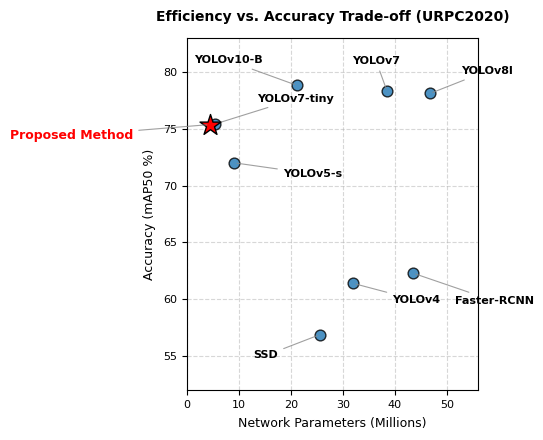

In [3]:
import matplotlib.pyplot as plt

models = [
    'SSD', 'YOLOv4', 'Faster-RCNN', 'YOLOv5-s',
    'YOLOv7', 'YOLOv8l', 'YOLOv10-B', 'YOLOv7-tiny', 'Proposed Method'
]

params = [25.6, 32.0, 43.5, 9.1, 38.5, 46.8, 21.2, 5.476, 4.370]
map50 = [56.9, 61.4, 62.3, 72.0, 78.3, 78.1, 78.8, 75.42, 75.36]

plt.figure(figsize=(5.2, 4.5))
plt.grid(True, linestyle='--', alpha=0.5, zorder=1)

arrow_style = dict(arrowstyle="-", color="#888888", lw=0.8, alpha=0.8)

layout_config = {
    'Proposed Method': (-55, -8, 'right'),
    'YOLOv7-tiny':     (30, 18, 'left'),
    'YOLOv5-s':        (35, -8, 'left'),

    'YOLOv10-B':       (-25, 18, 'right'),
    'YOLOv7':          (-8, 22, 'center'),
    'YOLOv8l':         (22, 16, 'left'),

    'SSD':             (-30, -15, 'right'),
    'YOLOv4':          (28, -12, 'left'),
    'Faster-RCNN':     (30, -20, 'left')
}

for i, name in enumerate(models):
    x, y = params[i], map50[i]
    x_off, y_off, h_align = layout_config[name]

    if name == 'Proposed Method':
        plt.scatter(x, y, color='red', marker='*', s=250, edgecolors='black', zorder=5)
    else:
        plt.scatter(x, y, color='#1f77b4', s=60, edgecolors='black', alpha=0.8, zorder=3)

    plt.annotate(
        name, (x, y),
        textcoords="offset points",
        xytext=(x_off, y_off),
        ha=h_align,
        va='center',
        fontsize=9 if name == 'Proposed Method' else 8,
        color='red' if name == 'Proposed Method' else 'black',
        weight='bold' if name == 'Proposed Method' else 'semibold',
        arrowprops=arrow_style,
        zorder=6 if name == 'Proposed Method' else 4,
        annotation_clip=False
    )

plt.title('Efficiency vs. Accuracy Trade-off (URPC2020)', fontsize=10, weight='bold', pad=12)
plt.xlabel('Network Parameters (Millions)', fontsize=9, labelpad=5)
plt.ylabel('Accuracy (mAP50 %)', fontsize=9, labelpad=5)

plt.xlim(0, 56)
plt.ylim(52, 83)

plt.xticks(fontsize=8)
plt.yticks(fontsize=8)

plt.tight_layout()
plt.savefig('teaser_updated_test_results.png', dpi=300)
plt.show()

# 7A. Automatic Qualitative Comparison Crop Generation
This cell generates full and automatically cropped comparison panels using ground truth boxes.
It compares ground truth, baseline detection, and proposed detection for selected test images.

In [ ]:
import cv2
import yaml
import numpy as np
from pathlib import Path

# ============================================================
# 1. CONFIGURATION
# ============================================================

PROJECT_ROOT = Path(
    r"C:\Users\User\Documents\Year 3 (Sem 3)\Computer Vision\Final Project\code\DU-MobileYOLO"
)

DATASET_ROOT = PROJECT_ROOT / "URPC2020" / "URPC2020"

RUNS_DETECT_ROOT = PROJECT_ROOT / "runs" / "detect"

SPLIT = "test"

OUTPUT_DIR = PROJECT_ROOT / "comparison_output"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

IMAGE_IDS = [1, 2, 8, 19]

# Map each image to its own baseline/proposed folder
COMPARE_MAP = {
    1: {
        "baseline": RUNS_DETECT_ROOT / "baseline1",
        "proposed": RUNS_DETECT_ROOT / "proposed1",
    },
    2: {
        "baseline": RUNS_DETECT_ROOT / "baseline2",
        "proposed": RUNS_DETECT_ROOT / "proposed2",
    },
    8: {
        "baseline": RUNS_DETECT_ROOT / "baseline3",
        "proposed": RUNS_DETECT_ROOT / "proposed3",
    },
    19: {
        "baseline": RUNS_DETECT_ROOT / "baseline4",
        "proposed": RUNS_DETECT_ROOT / "proposed4",
    },
}

ZERO_PAD = 6
CROP_PADDING_RATIO = 0.35


# ============================================================
# 2. LOAD CLASS NAMES
# ============================================================

yaml_path = DATASET_ROOT / "data.yaml"

with open(yaml_path, "r", encoding="utf-8") as f:
    data_yaml = yaml.safe_load(f)

names = data_yaml["names"]

if isinstance(names, dict):
    class_names = [names[i] for i in range(len(names))]
else:
    class_names = names

print("Loaded classes:", class_names)


# ============================================================
# 3. HELPER FUNCTIONS
# ============================================================

def make_stem(image_id):
    if ZERO_PAD > 0:
        return str(image_id).zfill(ZERO_PAD)
    return str(image_id)


def find_image(folder, image_id):
    stem = make_stem(image_id)

    possible_exts = [".jpg", ".jpeg", ".png", ".bmp"]

    for ext in possible_exts:
        p = folder / f"{stem}{ext}"
        if p.exists():
            return p

    # Recursive fallback
    for ext in possible_exts:
        candidates = list(folder.rglob(f"{stem}{ext}"))
        if candidates:
            return candidates[0]

    return None


def find_original_image(dataset_root, split, image_id):
    stem = make_stem(image_id)

    possible_exts = [".jpg", ".jpeg", ".png", ".bmp"]

    possible_dirs = [
        dataset_root / "images" / split,
        dataset_root / split / "images",
        dataset_root / split,
    ]

    for folder in possible_dirs:
        if not folder.exists():
            continue

        for ext in possible_exts:
            p = folder / f"{stem}{ext}"
            if p.exists():
                return p

        for ext in possible_exts:
            candidates = list(folder.rglob(f"{stem}{ext}"))
            if candidates:
                return candidates[0]

    return None


def find_label_file(dataset_root, split, image_stem):
    possible_dirs = [
        dataset_root / "labels" / split,
        dataset_root / split / "labels",
        dataset_root / split,
    ]

    for folder in possible_dirs:
        if not folder.exists():
            continue

        p = folder / f"{image_stem}.txt"
        if p.exists():
            return p

        candidates = list(folder.rglob(f"{image_stem}.txt"))
        if candidates:
            return candidates[0]

    return None


def yolo_to_xyxy(cls, xc, yc, bw, bh, img_w, img_h):
    x1 = int((xc - bw / 2) * img_w)
    y1 = int((yc - bh / 2) * img_h)
    x2 = int((xc + bw / 2) * img_w)
    y2 = int((yc + bh / 2) * img_h)

    x1 = max(0, min(x1, img_w - 1))
    y1 = max(0, min(y1, img_h - 1))
    x2 = max(0, min(x2, img_w - 1))
    y2 = max(0, min(y2, img_h - 1))

    return int(cls), x1, y1, x2, y2


def draw_ground_truth(image, label_path):
    img = image.copy()
    h, w = img.shape[:2]

    gt_boxes = []

    if label_path is None or not label_path.exists():
        print("Warning: ground-truth label not found.")
        return img, gt_boxes

    with open(label_path, "r", encoding="utf-8") as f:
        lines = f.readlines()

    for line in lines:
        parts = line.strip().split()

        if len(parts) < 5:
            continue

        cls = int(float(parts[0]))
        xc, yc, bw, bh = map(float, parts[1:5])

        cls, x1, y1, x2, y2 = yolo_to_xyxy(cls, xc, yc, bw, bh, w, h)

        gt_boxes.append((x1, y1, x2, y2))

        label_text = class_names[cls] if cls < len(class_names) else str(cls)

        cv2.rectangle(img, (x1, y1), (x2, y2), (0, 255, 0), 3)

        cv2.putText(
            img,
            f"GT: {label_text}",
            (x1, max(25, y1 - 8)),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.7,
            (0, 255, 0),
            2,
            cv2.LINE_AA,
        )

    return img, gt_boxes


def add_title(image, title):
    h, w = image.shape[:2]

    title_bar = np.ones((60, w, 3), dtype=np.uint8) * 255

    cv2.putText(
        title_bar,
        title,
        (20, 40),
        cv2.FONT_HERSHEY_SIMPLEX,
        1.1,
        (0, 0, 0),
        2,
        cv2.LINE_AA,
    )

    return np.vstack([title_bar, image])


def resize_to_same_height(images, target_height=520):
    resized = []

    for img in images:
        h, w = img.shape[:2]
        scale = target_height / h
        new_w = int(w * scale)
        resized_img = cv2.resize(img, (new_w, target_height))
        resized.append(resized_img)

    return resized


def make_panel(gt_img, baseline_img, proposed_img):
    images = resize_to_same_height(
        [gt_img, baseline_img, proposed_img],
        target_height=520
    )

    gt_titled = add_title(images[0], "Ground Truth")
    baseline_titled = add_title(images[1], "Baseline")
    proposed_titled = add_title(images[2], "Proposed")

    panel = np.hstack([gt_titled, baseline_titled, proposed_titled])

    return panel


def get_crop_region(gt_boxes, img_w, img_h, padding_ratio=0.35):
    if len(gt_boxes) == 0:
        return 0, 0, img_w, img_h

    x1 = min([b[0] for b in gt_boxes])
    y1 = min([b[1] for b in gt_boxes])
    x2 = max([b[2] for b in gt_boxes])
    y2 = max([b[3] for b in gt_boxes])

    box_w = x2 - x1
    box_h = y2 - y1

    pad_x = int(box_w * padding_ratio)
    pad_y = int(box_h * padding_ratio)

    crop_x1 = max(0, x1 - pad_x)
    crop_y1 = max(0, y1 - pad_y)
    crop_x2 = min(img_w, x2 + pad_x)
    crop_y2 = min(img_h, y2 + pad_y)

    return crop_x1, crop_y1, crop_x2, crop_y2


def crop_image(img, crop_region):
    x1, y1, x2, y2 = crop_region
    return img[y1:y2, x1:x2]


# ============================================================
# 4. MAIN PROCESS
# ============================================================

for image_id in IMAGE_IDS:
    stem = make_stem(image_id)

    print("\n====================================================")
    print(f"Processing image: {stem}")
    print("====================================================")

    original_path = find_original_image(DATASET_ROOT, SPLIT, image_id)

    baseline_dir = COMPARE_MAP[image_id]["baseline"]
    proposed_dir = COMPARE_MAP[image_id]["proposed"]

    baseline_path = find_image(baseline_dir, image_id)
    proposed_path = find_image(proposed_dir, image_id)

    if original_path is None:
        print(f"Original image not found for {stem}")
        continue

    if baseline_path is None:
        print(f"Baseline result not found for {stem} in {baseline_dir}")
        continue

    if proposed_path is None:
        print(f"Proposed result not found for {stem} in {proposed_dir}")
        continue

    label_path = find_label_file(DATASET_ROOT, SPLIT, Path(original_path).stem)

    print("Original:", original_path)
    print("Label:", label_path)
    print("Baseline:", baseline_path)
    print("Proposed:", proposed_path)

    original_img = cv2.imread(str(original_path))
    baseline_img = cv2.imread(str(baseline_path))
    proposed_img = cv2.imread(str(proposed_path))

    if original_img is None:
        print("Failed to read original image.")
        continue

    if baseline_img is None:
        print("Failed to read baseline image.")
        continue

    if proposed_img is None:
        print("Failed to read proposed image.")
        continue

    h, w = original_img.shape[:2]

    baseline_img = cv2.resize(baseline_img, (w, h))
    proposed_img = cv2.resize(proposed_img, (w, h))

    gt_img, gt_boxes = draw_ground_truth(original_img, label_path)

    # Full comparison
    full_panel = make_panel(gt_img, baseline_img, proposed_img)
    full_save_path = OUTPUT_DIR / f"full_{stem}.jpg"
    cv2.imwrite(str(full_save_path), full_panel)

    # Cropped comparison
    crop_region = get_crop_region(gt_boxes, w, h, CROP_PADDING_RATIO)

    gt_crop = crop_image(gt_img, crop_region)
    baseline_crop = crop_image(baseline_img, crop_region)
    proposed_crop = crop_image(proposed_img, crop_region)

    crop_panel = make_panel(gt_crop, baseline_crop, proposed_crop)
    crop_save_path = OUTPUT_DIR / f"crop_{stem}.jpg"
    cv2.imwrite(str(crop_save_path), crop_panel)

    print("Saved full comparison:", full_save_path)
    print("Saved cropped comparison:", crop_save_path)

print("\nDone.")
print("Check output folder:", OUTPUT_DIR)

Loaded classes: ['holothurian', 'echinus', 'scallop', 'starfish']

Processing image: 000001
Original: C:\Users\User\Documents\Year 3 (Sem 3)\Computer Vision\Final Project\code\DU-MobileYOLO\URPC2020\URPC2020\test\images\000001.jpg
Label: C:\Users\User\Documents\Year 3 (Sem 3)\Computer Vision\Final Project\code\DU-MobileYOLO\URPC2020\URPC2020\test\labels\000001.txt
Baseline: C:\Users\User\Documents\Year 3 (Sem 3)\Computer Vision\Final Project\code\DU-MobileYOLO\runs\detect\baseline1\000001.jpg
Proposed: C:\Users\User\Documents\Year 3 (Sem 3)\Computer Vision\Final Project\code\DU-MobileYOLO\runs\detect\proposed1\000001.jpg
Saved full comparison: C:\Users\User\Documents\Year 3 (Sem 3)\Computer Vision\Final Project\code\DU-MobileYOLO\comparison_output\full_000001.jpg
Saved cropped comparison: C:\Users\User\Documents\Year 3 (Sem 3)\Computer Vision\Final Project\code\DU-MobileYOLO\comparison_output\crop_000001.jpg

Processing image: 000002
Original: C:\Users\User\Documents\Year 3 (Sem 3)\Com

# 7B. Manual Qualitative Crop Generation
This cell generates manually controlled crop regions for selected test images.
It is used when automatic cropping does not focus on the most informative detection area.

In [ ]:
import cv2
import yaml
import numpy as np
from pathlib import Path

# ============================================================
# 1. CONFIGURATION
# ============================================================

PROJECT_ROOT = Path(
    r"C:\Users\User\Documents\Year 3 (Sem 3)\Computer Vision\Final Project\code\DU-MobileYOLO"
)

DATASET_ROOT = PROJECT_ROOT / "URPC2020" / "URPC2020"
RUNS_DETECT_ROOT = PROJECT_ROOT / "runs" / "detect"

SPLIT = "test"

OUTPUT_DIR = PROJECT_ROOT / "comparison_output"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

IMAGE_IDS = [1, 2, 8, 19]

ZERO_PAD = 6

# ============================================================
# 2. MAP EACH IMAGE TO BASELINE / PROPOSED FOLDER
# ============================================================

COMPARE_MAP = {
    1: {
        "baseline": RUNS_DETECT_ROOT / "baseline1",
        "proposed": RUNS_DETECT_ROOT / "proposed1",
    },
    2: {
        "baseline": RUNS_DETECT_ROOT / "baseline2",
        "proposed": RUNS_DETECT_ROOT / "proposed2",
    },
    8: {
        "baseline": RUNS_DETECT_ROOT / "baseline3",
        "proposed": RUNS_DETECT_ROOT / "proposed3",
    },
    19: {
        "baseline": RUNS_DETECT_ROOT / "baseline4",
        "proposed": RUNS_DETECT_ROOT / "proposed4",
    },
}

# ============================================================
# 3. MANUAL CROP REGIONS
# ============================================================
# Format:
# image_id: (x1, y1, x2, y2)
# ============================================================

MANUAL_CROP_ROIS = {
    # Image 000001: focus middle-left region
    1: (70, 70, 470, 360),

    # Image 000002: focus bottom-middle object area
    2: (120, 180, 520, 470),

    # Image 000008: focus right-side detection difference
    8: (250, 100, 640, 420),

    # Image 000019: focus holothurian + scallop area
    19: (40, 80, 430, 470),
}

# Set True first if you want to click and find coordinates manually.
# After you get coordinates, set it back to False.
ENABLE_CLICK_COORDINATES = False


# ============================================================
# 4. LOAD CLASS NAMES
# ============================================================

yaml_path = DATASET_ROOT / "data.yaml"

with open(yaml_path, "r", encoding="utf-8") as f:
    data_yaml = yaml.safe_load(f)

names = data_yaml["names"]

if isinstance(names, dict):
    class_names = [names[i] for i in range(len(names))]
else:
    class_names = names

print("Loaded classes:", class_names)


# ============================================================
# 5. HELPER FUNCTIONS
# ============================================================

def make_stem(image_id):
    if ZERO_PAD > 0:
        return str(image_id).zfill(ZERO_PAD)
    return str(image_id)


def find_image(folder, image_id):
    stem = make_stem(image_id)
    possible_exts = [".jpg", ".jpeg", ".png", ".bmp"]

    for ext in possible_exts:
        p = folder / f"{stem}{ext}"
        if p.exists():
            return p

    for ext in possible_exts:
        candidates = list(folder.rglob(f"{stem}{ext}"))
        if candidates:
            return candidates[0]

    return None


def find_original_image(dataset_root, split, image_id):
    stem = make_stem(image_id)
    possible_exts = [".jpg", ".jpeg", ".png", ".bmp"]

    possible_dirs = [
        dataset_root / "images" / split,
        dataset_root / split / "images",
        dataset_root / split,
        dataset_root / "test",
        dataset_root / "valid",
        dataset_root / "train",
    ]

    for folder in possible_dirs:
        if not folder.exists():
            continue

        for ext in possible_exts:
            p = folder / f"{stem}{ext}"
            if p.exists():
                return p

        for ext in possible_exts:
            candidates = list(folder.rglob(f"{stem}{ext}"))
            if candidates:
                return candidates[0]

    return None


def find_label_file(dataset_root, split, image_stem):
    possible_dirs = [
        dataset_root / "labels" / split,
        dataset_root / split / "labels",
        dataset_root / split,
        dataset_root / "test",
        dataset_root / "valid",
        dataset_root / "train",
    ]

    for folder in possible_dirs:
        if not folder.exists():
            continue

        p = folder / f"{image_stem}.txt"
        if p.exists():
            return p

        candidates = list(folder.rglob(f"{image_stem}.txt"))
        if candidates:
            return candidates[0]

    return None


def yolo_to_xyxy(cls, xc, yc, bw, bh, img_w, img_h):
    x1 = int((xc - bw / 2) * img_w)
    y1 = int((yc - bh / 2) * img_h)
    x2 = int((xc + bw / 2) * img_w)
    y2 = int((yc + bh / 2) * img_h)

    x1 = max(0, min(x1, img_w - 1))
    y1 = max(0, min(y1, img_h - 1))
    x2 = max(0, min(x2, img_w - 1))
    y2 = max(0, min(y2, img_h - 1))

    return int(cls), x1, y1, x2, y2


def draw_ground_truth(image, label_path, image_id=None):
    img = image.copy()
    h, w = img.shape[:2]

    gt_boxes = []

    if label_path is None or not label_path.exists():
        print("Warning: ground-truth label not found.")
        return img, gt_boxes

    with open(label_path, "r", encoding="utf-8") as f:
        lines = f.readlines()

    print(f"\nGround-truth boxes for image {make_stem(image_id) if image_id is not None else ''}:")

    for idx, line in enumerate(lines):
        parts = line.strip().split()

        if len(parts) < 5:
            continue

        cls = int(float(parts[0]))
        xc, yc, bw, bh = map(float, parts[1:5])

        cls, x1, y1, x2, y2 = yolo_to_xyxy(cls, xc, yc, bw, bh, w, h)

        gt_boxes.append((x1, y1, x2, y2))

        label_text = class_names[cls] if cls < len(class_names) else str(cls)

        print(f"  Box {idx + 1}: class={label_text}, x1={x1}, y1={y1}, x2={x2}, y2={y2}")

        cv2.rectangle(img, (x1, y1), (x2, y2), (0, 255, 0), 3)

        cv2.putText(
            img,
            f"GT: {label_text}",
            (x1, max(25, y1 - 8)),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.65,
            (0, 255, 0),
            2,
            cv2.LINE_AA,
        )

    return img, gt_boxes


def add_title(image, title):
    h, w = image.shape[:2]

    title_bar = np.ones((45, w, 3), dtype=np.uint8) * 255

    cv2.putText(
        title_bar,
        title,
        (12, 32),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.85,
        (0, 0, 0),
        2,
        cv2.LINE_AA,
    )

    return np.vstack([title_bar, image])


def resize_to_same_height(images, target_height=420):
    resized = []

    for img in images:
        h, w = img.shape[:2]

        if h == 0 or w == 0:
            raise ValueError("One crop image is empty. Check your crop coordinates.")

        scale = target_height / h
        new_w = int(w * scale)

        resized_img = cv2.resize(img, (new_w, target_height))
        resized.append(resized_img)

    return resized


def make_panel(gt_img, baseline_img, proposed_img, target_height=420):
    images = resize_to_same_height(
        [gt_img, baseline_img, proposed_img],
        target_height=target_height
    )

    gt_titled = add_title(images[0], "Ground Truth")
    baseline_titled = add_title(images[1], "Baseline")
    proposed_titled = add_title(images[2], "Proposed")

    panel = np.hstack([gt_titled, baseline_titled, proposed_titled])
    return panel


def crop_image(img, crop_region):
    h, w = img.shape[:2]

    x1, y1, x2, y2 = crop_region

    x1 = max(0, min(x1, w - 1))
    y1 = max(0, min(y1, h - 1))
    x2 = max(1, min(x2, w))
    y2 = max(1, min(y2, h))

    if x2 <= x1 or y2 <= y1:
        raise ValueError(f"Invalid crop region: {crop_region}")

    return img[y1:y2, x1:x2]


def get_auto_crop_from_selected_gt(gt_boxes, selected_indices, img_w, img_h, padding=50):
    """
    Crop based on selected GT box indices.
    Example:
    selected_indices = [0] means crop only GT box 1.
    selected_indices = [0, 2] means crop GT box 1 and 3 together.
    """
    selected_boxes = []

    for idx in selected_indices:
        if idx < len(gt_boxes):
            selected_boxes.append(gt_boxes[idx])

    if len(selected_boxes) == 0:
        return 0, 0, img_w, img_h

    x1 = min([b[0] for b in selected_boxes])
    y1 = min([b[1] for b in selected_boxes])
    x2 = max([b[2] for b in selected_boxes])
    y2 = max([b[3] for b in selected_boxes])

    x1 = max(0, x1 - padding)
    y1 = max(0, y1 - padding)
    x2 = min(img_w, x2 + padding)
    y2 = min(img_h, y2 + padding)

    return x1, y1, x2, y2


def show_image_coordinates(image, window_name="Click image"):
    """
    Left-click image to print x,y coordinates.
    Press ESC or any key to close.
    """
    clone = image.copy()

    def mouse_callback(event, x, y, flags, param):
        if event == cv2.EVENT_LBUTTONDOWN:
            print(f"Clicked coordinate: x={x}, y={y}")

            temp = clone.copy()
            cv2.circle(temp, (x, y), 6, (0, 0, 255), -1)
            cv2.putText(
                temp,
                f"({x}, {y})",
                (x + 10, y - 10),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.7,
                (0, 0, 255),
                2,
                cv2.LINE_AA,
            )
            cv2.imshow(window_name, temp)

    cv2.imshow(window_name, clone)
    cv2.setMouseCallback(window_name, mouse_callback)
    cv2.waitKey(0)
    cv2.destroyAllWindows()


def draw_crop_box_preview(image, crop_region):
    preview = image.copy()
    x1, y1, x2, y2 = crop_region

    cv2.rectangle(preview, (x1, y1), (x2, y2), (0, 0, 255), 4)

    cv2.putText(
        preview,
        "Crop Region",
        (x1, max(30, y1 - 10)),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.9,
        (0, 0, 255),
        2,
        cv2.LINE_AA,
    )

    return preview


# ============================================================
# 6. MAIN PROCESS
# ============================================================

for image_id in IMAGE_IDS:
    stem = make_stem(image_id)

    print("\n====================================================")
    print(f"Processing image: {stem}")
    print("====================================================")

    original_path = find_original_image(DATASET_ROOT, SPLIT, image_id)

    baseline_dir = COMPARE_MAP[image_id]["baseline"]
    proposed_dir = COMPARE_MAP[image_id]["proposed"]

    baseline_path = find_image(baseline_dir, image_id)
    proposed_path = find_image(proposed_dir, image_id)

    if original_path is None:
        print(f"Original image not found for {stem}")
        continue

    if baseline_path is None:
        print(f"Baseline result not found for {stem} in {baseline_dir}")
        continue

    if proposed_path is None:
        print(f"Proposed result not found for {stem} in {proposed_dir}")
        continue

    label_path = find_label_file(DATASET_ROOT, SPLIT, Path(original_path).stem)

    print("Original:", original_path)
    print("Label:", label_path)
    print("Baseline:", baseline_path)
    print("Proposed:", proposed_path)

    original_img = cv2.imread(str(original_path))
    baseline_img = cv2.imread(str(baseline_path))
    proposed_img = cv2.imread(str(proposed_path))

    if original_img is None:
        print("Failed to read original image.")
        continue

    if baseline_img is None:
        print("Failed to read baseline image.")
        continue

    if proposed_img is None:
        print("Failed to read proposed image.")
        continue

    h, w = original_img.shape[:2]

    baseline_img = cv2.resize(baseline_img, (w, h))
    proposed_img = cv2.resize(proposed_img, (w, h))

    gt_img, gt_boxes = draw_ground_truth(original_img, label_path, image_id=image_id)

    if ENABLE_CLICK_COORDINATES:
        show_image_coordinates(gt_img, f"Click crop points for {stem}")

    # ========================================================
    # Full comparison image
    # ========================================================

    full_panel = make_panel(
        gt_img,
        baseline_img,
        proposed_img,
        target_height=520
    )

    full_save_path = OUTPUT_DIR / f"full_{stem}.jpg"
    cv2.imwrite(str(full_save_path), full_panel)

    # ========================================================
    # Manual cropped comparison image
    # ========================================================

    if image_id in MANUAL_CROP_ROIS:
        crop_region = MANUAL_CROP_ROIS[image_id]
        print("Using manual crop region:", crop_region)
    else:
        # Fallback: crop around first GT box only
        crop_region = get_auto_crop_from_selected_gt(
            gt_boxes,
            selected_indices=[0],
            img_w=w,
            img_h=h,
            padding=80
        )
        print("Using automatic first-GT crop region:", crop_region)

    gt_crop = crop_image(gt_img, crop_region)
    baseline_crop = crop_image(baseline_img, crop_region)
    proposed_crop = crop_image(proposed_img, crop_region)

    crop_panel = make_panel(
        gt_crop,
        baseline_crop,
        proposed_crop,
        target_height=420
    )

    crop_save_path = OUTPUT_DIR / f"crop_{stem}.jpg"
    cv2.imwrite(str(crop_save_path), crop_panel)

    # ========================================================
    # Save crop preview image
    # ========================================================

    crop_preview = draw_crop_box_preview(gt_img, crop_region)

    preview_save_path = OUTPUT_DIR / f"preview_crop_region_{stem}.jpg"
    cv2.imwrite(str(preview_save_path), crop_preview)

    print("Saved full comparison:", full_save_path)
    print("Saved cropped comparison:", crop_save_path)
    print("Saved crop preview:", preview_save_path)

print("\nDone.")
print("Check output folder:", OUTPUT_DIR)

Loaded classes: ['holothurian', 'echinus', 'scallop', 'starfish']

Processing image: 000001
Original: C:\Users\User\Documents\Year 3 (Sem 3)\Computer Vision\Final Project\code\DU-MobileYOLO\URPC2020\URPC2020\test\images\000001.jpg
Label: C:\Users\User\Documents\Year 3 (Sem 3)\Computer Vision\Final Project\code\DU-MobileYOLO\URPC2020\URPC2020\test\labels\000001.txt
Baseline: C:\Users\User\Documents\Year 3 (Sem 3)\Computer Vision\Final Project\code\DU-MobileYOLO\runs\detect\baseline1\000001.jpg
Proposed: C:\Users\User\Documents\Year 3 (Sem 3)\Computer Vision\Final Project\code\DU-MobileYOLO\runs\detect\proposed1\000001.jpg

Ground-truth boxes for image 000001:
  Box 1: class=echinus, x1=552, y1=86, x2=711, y2=226
  Box 2: class=echinus, x1=739, y1=984, x2=851, y2=1068
  Box 3: class=echinus, x1=645, y1=834, x2=754, y2=932
  Box 4: class=echinus, x1=1644, y1=978, x2=1791, y2=1079
  Box 5: class=echinus, x1=1402, y1=967, x2=1569, y2=1076
  Box 6: class=echinus, x1=1185, y1=953, x2=1314, y2

# 7C. Final Report Qualitative Crop Export
This cell exports fixed-size qualitative crops used for the final report figure.
It saves Original, Ground Truth, Baseline, and Proposed crops with the same output size.

In [15]:
import cv2
import numpy as np
from pathlib import Path

# ============================================================
# Run this script from your DU-MobileYOLO project root
# ============================================================
ROOT = Path.cwd()

SAVE_DIR = ROOT / "runs" / "qualitative_crops"
SAVE_DIR.mkdir(parents=True, exist_ok=True)

BASE_W, BASE_H = 1600, 900
INCLUDE_ORIGINAL = True
OUTPUT_W, OUTPUT_H = 640, 360

GT_BOX_COLOR = (0, 255, 0)
GT_BOX_THICKNESS = 2

CLASS_NAMES = [
    "holothurian",
    "echinus",
    "scallop",
    "starfish"
]

CASES = {
    "image_1_top_right_echinus_cluster": {
        "crop": (960, 70, 1600, 430),
        "image_path": ROOT / "URPC2020" / "URPC2020" / "test" / "images" / "000001.jpg",
        "label_path": ROOT / "URPC2020" / "URPC2020" / "test" / "labels" / "000001.txt",
        "baseline_path": ROOT / "runs" / "detect" / "baseline1" / "000001.jpg",
        "proposed_path": ROOT / "runs" / "detect" / "proposed1" / "000001.jpg",
    },

    "image_8_upper_missed_holothurian": {
        "crop": (480, 0, 1180, 390),
        "image_path": ROOT / "URPC2020" / "URPC2020" / "test" / "images" / "000008.jpg",
        "label_path": ROOT / "URPC2020" / "URPC2020" / "test" / "labels" / "000008.txt",
        "baseline_path": ROOT / "runs" / "detect" / "baseline3" / "000008.jpg",
        "proposed_path": ROOT / "runs" / "detect" / "proposed3" / "000008.jpg",
    },

    "image_8_low_contrast_region": {
        "crop": (680, 400, 1290, 780),
        "image_path": ROOT / "URPC2020" / "URPC2020" / "test" / "images" / "000008.jpg",
        "label_path": ROOT / "URPC2020" / "URPC2020" / "test" / "labels" / "000008.txt",
        "baseline_path": ROOT / "runs" / "detect" / "baseline3" / "000008.jpg",
        "proposed_path": ROOT / "runs" / "detect" / "proposed3" / "000008.jpg",
    }
}


def read_image(path):
    img = cv2.imread(str(path), cv2.IMREAD_COLOR)
    if img is None:
        raise FileNotFoundError(f"Cannot read image: {path}")
    return img


def scale_crop(crop, img_w, img_h):
    x1, y1, x2, y2 = crop

    sx = img_w / BASE_W
    sy = img_h / BASE_H

    x1 = int(round(x1 * sx))
    x2 = int(round(x2 * sx))
    y1 = int(round(y1 * sy))
    y2 = int(round(y2 * sy))

    x1 = max(0, min(x1, img_w - 1))
    x2 = max(1, min(x2, img_w))
    y1 = max(0, min(y1, img_h - 1))
    y2 = max(1, min(y2, img_h))

    return x1, y1, x2, y2


def crop_and_resize(img, crop):
    h, w = img.shape[:2]
    x1, y1, x2, y2 = scale_crop(crop, w, h)

    cropped = img[y1:y2, x1:x2]

    cropped = cv2.resize(
        cropped,
        (OUTPUT_W, OUTPUT_H),
        interpolation=cv2.INTER_AREA
    )

    return cropped


def draw_gt_boxes_with_labels(image_path, label_path):
    """
    Draw YOLO ground-truth boxes with species name only.
    """
    img = read_image(image_path).copy()
    h, w = img.shape[:2]

    if not Path(label_path).exists():
        print(f"Warning: Label file not found: {label_path}")
        return img

    with open(label_path, "r") as f:
        lines = f.readlines()

    for line in lines:
        parts = line.strip().split()
        if len(parts) != 5:
            continue

        cls_id, xc, yc, bw, bh = map(float, parts)
        cls_id = int(cls_id)

        xc *= w
        yc *= h
        bw *= w
        bh *= h

        x1 = int(xc - bw / 2)
        y1 = int(yc - bh / 2)
        x2 = int(xc + bw / 2)
        y2 = int(yc + bh / 2)

        x1 = max(0, min(x1, w - 1))
        y1 = max(0, min(y1, h - 1))
        x2 = max(0, min(x2, w - 1))
        y2 = max(0, min(y2, h - 1))

        if 0 <= cls_id < len(CLASS_NAMES):
            class_name = CLASS_NAMES[cls_id]
        else:
            class_name = f"class_{cls_id}"

        cv2.rectangle(img, (x1, y1), (x2, y2), GT_BOX_COLOR, GT_BOX_THICKNESS)

        font = cv2.FONT_HERSHEY_SIMPLEX
        font_scale = 0.6
        thickness = 2
        (tw, th), baseline = cv2.getTextSize(class_name, font, font_scale, thickness)

        text_x = x1
        text_y = y1 - 8
        if text_y - th < 0:
            text_y = y1 + th + 8

        cv2.rectangle(
            img,
            (text_x, text_y - th - baseline),
            (text_x + tw, text_y + baseline),
            GT_BOX_COLOR,
            -1
        )

        cv2.putText(
            img,
            class_name,
            (text_x, text_y),
            font,
            font_scale,
            (0, 0, 0),
            thickness,
            cv2.LINE_AA
        )

    return img


def make_panel(crops, labels):
    title_h = 45
    panel_images = []

    for crop, label in zip(crops, labels):
        canvas = np.ones((OUTPUT_H + title_h, OUTPUT_W, 3), dtype=np.uint8) * 255
        canvas[title_h:, :, :] = crop

        cv2.putText(
            canvas,
            label,
            (15, 30),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.9,
            (0, 0, 0),
            2,
            cv2.LINE_AA
        )

        panel_images.append(canvas)

    return np.hstack(panel_images)


for case_name, info in CASES.items():
    print(f"\nProcessing: {case_name}")

    case_dir = SAVE_DIR / case_name
    case_dir.mkdir(parents=True, exist_ok=True)

    original_img = read_image(info["image_path"])
    gt_img = draw_gt_boxes_with_labels(info["image_path"], info["label_path"])
    baseline_img = read_image(info["baseline_path"])
    proposed_img = read_image(info["proposed_path"])

    image_dict = {}

    if INCLUDE_ORIGINAL:
        image_dict["Original"] = original_img

    image_dict["Ground Truth"] = gt_img
    image_dict["Baseline"] = baseline_img
    image_dict["Proposed"] = proposed_img

    crops = []
    labels = []

    for label, img in image_dict.items():
        crop = crop_and_resize(img, info["crop"])

        save_path = case_dir / f"{label.replace(' ', '_')}.png"
        cv2.imwrite(str(save_path), crop)

        crops.append(crop)
        labels.append(label)

        print(f"Saved {label}: {save_path} | size: {crop.shape[1]}x{crop.shape[0]}")

    panel = make_panel(crops, labels)
    panel_path = SAVE_DIR / f"{case_name}_comparison.png"
    cv2.imwrite(str(panel_path), panel)

    print(f"Saved comparison panel: {panel_path}")

print("\nDone. All crops are saved with the same size.")


Processing: image_1_top_right_echinus_cluster
Saved Original: c:\Users\User\Documents\Year 3 (Sem 3)\Computer Vision\Final Project\code\DU-MobileYOLO\runs\qualitative_crops\image_1_top_right_echinus_cluster\Original.png | size: 640x360
Saved Ground Truth: c:\Users\User\Documents\Year 3 (Sem 3)\Computer Vision\Final Project\code\DU-MobileYOLO\runs\qualitative_crops\image_1_top_right_echinus_cluster\Ground_Truth.png | size: 640x360
Saved Baseline: c:\Users\User\Documents\Year 3 (Sem 3)\Computer Vision\Final Project\code\DU-MobileYOLO\runs\qualitative_crops\image_1_top_right_echinus_cluster\Baseline.png | size: 640x360
Saved Proposed: c:\Users\User\Documents\Year 3 (Sem 3)\Computer Vision\Final Project\code\DU-MobileYOLO\runs\qualitative_crops\image_1_top_right_echinus_cluster\Proposed.png | size: 640x360
Saved comparison panel: c:\Users\User\Documents\Year 3 (Sem 3)\Computer Vision\Final Project\code\DU-MobileYOLO\runs\qualitative_crops\image_1_top_right_echinus_cluster_comparison.png

